In [154]:
import warnings
warnings.filterwarnings('ignore')
import anndata as ad, scanpy as sc, squidpy as sq, pandas as pd, numpy as np, seaborn as sns, matplotlib as mpl, matplotlib.pyplot as plt
import sys, os 

In [3]:
# Pre-set figure settings
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams["font.sans-serif"] = "Arial"

# Display setting for MacOS
#%config InlineBackend.figure_format = 'retina'

# Settings for scanpy
sc.settings.verbosity = 3 # this determines the amount of description in output 
sc.settings.set_figure_params(dpi=50, dpi_save=300, frameon=False, figsize=(4, 4), facecolor='white') # figure settings
sc.logging.print_versions() # check all package versions

Component,Info
Python,"3.10.13 | packaged by conda-forge | (main, Dec 23 2023, 15:35:25) [Clang 16.0.6 ]"
OS,macOS-15.5-arm64-arm-64bit
CPU,"16 logical CPU cores, arm"
GPU,No GPU found
Updated,2025-09-23 04:32
Dependency,Version
jaraco.text,3.12.1
parso,0.8.4
validators,0.35.0
tqdm,4.67.1


In [155]:
# Specify the path to the data
root_path = "/Users/xinyubai/Documents/01_Research.projects/03ITM_immunotherapy/ITM_spatial_analysis/cell_composition/" # inset your own path

data_path = "/Users/xinyubai/Documents/01_Research.projects/03ITM_immunotherapy/ITM_spatial_analysis/anndata_obj/" # where the data is stored

# where you want to store the output
output_dir = root_path + 'output/'

os.makedirs(output_dir, exist_ok=True)

In [16]:
adata = sc.read_h5ad(data_path + "itm18_annotated_cn.h5ad")

In [17]:
adata

AnnData object with n_obs × n_vars = 3553478 × 39
    obs: 'sample', 'Object.ID', 'Image.ID', 'timepoint', 'treatment', 'response', 'treat_setting', 'cell_lineage', 'immune_stroma_lineage', 'cell_type_major', 'immune_stroma_lineage_str', 'immune_subtype', 'myeloid_subtype', 'Tcell_subtype', 'cell_type_minor', 'immune_subtype_str', 'myeloid_subtype_str', 'Tcell_subtype_str', 'pt_response', 'neighborhood20', 'region', 'region_tumour_stroma', 'region_tumour_margin_stroma', 'x', 'y', 'CN_k20_n20', 'CN_k20_n7', 'summary_cell_type', 'CN_k20_n7_annot', 'response_group', 'response_group_ordered'
    uns: 'CN_k20_n7_colors', 'Centroid_k20_n20', 'Centroid_k20_n7', 'cell_type_major_colors', 'dendrogram_Tcell_subtype', 'dendrogram_cell_lineage', 'dendrogram_cell_type_major', 'dendrogram_cell_type_minor', 'dendrogram_immune_subtype', 'dendrogram_myeloid_subtype', 'dendrogram_pt_response'
    obsm: 'spatial'

In [18]:
adata.obs.head()

,sample,Object.ID,Image.ID,timepoint,treatment,response,treat_setting,cell_lineage,immune_stroma_lineage,cell_type_major,...,region_tumour_stroma,region_tumour_margin_stroma,x,y,CN_k20_n20,CN_k20_n7,summary_cell_type,CN_k20_n7_annot,response_group,response_group_ordered
0,S10,f9d9c7be-1d0b-4b34-a02a-e0627d250d31,S10_PROG_PD1_repro,PROG,antiPD1,Resistant,Advanced_met,Melanoma,NaN,Melanoma,...,Tumour,Tumour,1408.8,19.28,1,1,Melanoma,Tumour core,PROG_Resistant,2PROG_Resistant
1,S10,2b0737d3-e88e-4430-9612-3c11cbf18b3c,S10_PROG_PD1_repro,PROG,antiPD1,Resistant,Advanced_met,Melanoma,NaN,Melanoma,...,Tumour,Tumour,1353.6,19.25,7,1,Melanoma,Tumour core,PROG_Resistant,2PROG_Resistant
2,S10,8fcd77d1-2fbb-4103-a5e2-b7b6c43080ed,S10_PROG_PD1_repro,PROG,antiPD1,Resistant,Advanced_met,Melanoma,NaN,Melanoma,...,Tumour,Tumour,1321.6,19.62,7,1,Melanoma,Tumour core,PROG_Resistant,2PROG_Resistant
3,S10,26d7bac6-2282-465e-941b-fe830f1c756e,S10_PROG_PD1_repro,PROG,antiPD1,Resistant,Advanced_met,Melanoma,NaN,Melanoma,...,Tumour,Tumour,1437.6,19.76,6,4,Melanoma,Tumour macrophage,PROG_Resistant,2PROG_Resistant
4,S10,262dab36-2cbf-49dc-99e3-b11c46385e08,S10_PROG_PD1_repro,PROG,antiPD1,Resistant,Advanced_met,Melanoma,NaN,Melanoma,...,Tumour,Tumour,1331.9,20.56,7,1,Melanoma,Tumour core,PROG_Resistant,2PROG_Resistant


In [19]:
sc.pp.scale(adata)
sc.pp.combat(adata, key='sample')
sc.pp.pca(adata)
sc.pp.neighbors(adata, n_neighbors=15, knn=True, method='umap')
sc.tl.umap(adata, method='umap')
sc.tl.leiden(adata, resolution=0.2, key_added="itm18_leiden")

Standardizing Data across genes.

Found 18 batches

Found 0 numerical variables:
	

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting data

computing PCA
    with n_comps=38
    finished (0:00:05)
computing neighbors
    using data matrix X directly


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:06:33)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:23:45)
running Leiden clustering


IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out


    finished: found 25 clusters and added
    'itm18_leiden', the cluster labels (adata.obs, categorical) (5:32:04)


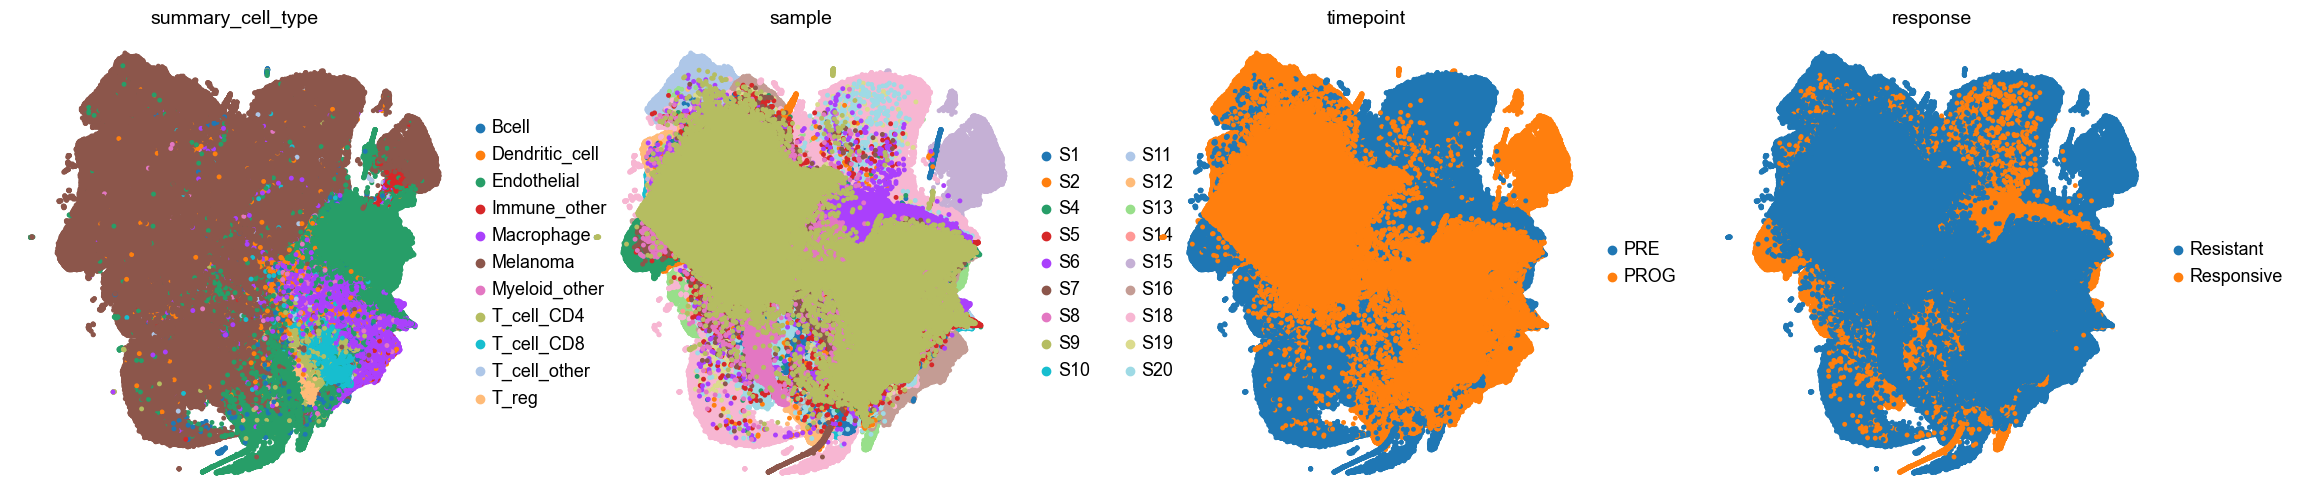

In [20]:
from matplotlib.pyplot import rc_context
with rc_context({'figure.figsize': (6, 6)}):
    sc.pl.umap(adata, color=['summary_cell_type','sample', 'timepoint', 'response'], s=50, frameon=False, ncols=4, vmax='p99')

In [ ]:
### Tuning the clustering and dimensionality reduction parameters

In [21]:
import itertools as it
import matplotlib.pyplot as plt
import scanpy as sc

# -----------------------
# CONFIG: try these first
# -----------------------
param_grid = {
    "n_pcs":      [20, 30],          # how many PCs go into the graph
    "n_neighbors":[10, 15, 20],      # local connectivity
    "metric":     ["cosine", "euclidean"],
    "min_dist":   [0.2, 0.3, 0.5],   # tighter clusters at lower values
}
random_state = 0                     # reproducible UMAP
spread = 1.5                         # mild global separation
colors = ['summary_cell_type','sample','timepoint','response']
dot_size = 50

# (Optional) if you haven't already, ensure PCA exists with enough comps
# sc.pp.pca(adata, n_comps=max(param_grid["n_pcs"]))

# -----------------------
# Helper: compute & store
# -----------------------
def compute_umap_variant(adata, n_pcs, n_neighbors, metric, min_dist,
                         spread=1.5, random_state=0, label=None):
    """
    Recompute neighbors and UMAP with given params, then store in adata.obsm['X_umap_<label>'].
    Returns the label actually used.
    """
    if label is None:
        label = f"pcs{n_pcs}_nn{n_neighbors}_{metric}_md{min_dist}".replace('.', 'p')
    # Recompute graph for this config
    sc.pp.neighbors(
        adata,
        n_neighbors=n_neighbors,
        n_pcs=n_pcs,
        metric=metric,
        knn=True,
        method='umap'
    )
    # Compute UMAP
    sc.tl.umap(
        adata,
        min_dist=min_dist,
        spread=spread,
        random_state=random_state,
        init_pos='spectral'  # often helps separation/reproducibility
    )
    # Store embedding under a unique basis
    adata.obsm[f"X_umap_{label}"] = adata.obsm["X_umap"].copy()
    return label

In [ ]:
### Testing on subsample

In [24]:
# Make a 10% subsampled copy
adata_sub = sc.pp.subsample(adata, fraction=0.1, random_state=0, copy=True)

# Test the parameter loop *on adata_sub* instead of the full adata
results = []
for n_pcs, n_neighbors, metric, min_dist in it.product(
        param_grid["n_pcs"], param_grid["n_neighbors"],
        param_grid["metric"], param_grid["min_dist"]):
    lbl = compute_umap_variant(
        adata_sub,
        n_pcs=n_pcs,
        n_neighbors=n_neighbors,
        metric=metric,
        min_dist=min_dist,
        spread=spread,
        random_state=random_state
    )
    results.append(lbl)
    with plt.rc_context({'figure.figsize': (6, 6)}):
        sc.pl.embedding(
            adata_sub,
            basis=f"umap_{lbl}",
            color=colors,
            s=dot_size,
            frameon=False,
            show=False
        )
        plt.suptitle(lbl, y=0.98, fontsize=10)
        plt.savefig(f"umap_overview_subsample_{lbl}.png", dpi=300, bbox_inches="tight")
        plt.close()

computing neighbors
    using data matrix X directly
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:20)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:01:36)
computing neighbors
    using data matrix X directly
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:20)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:01:36)
computing neighbors
    using data matrix X directly
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:20)
computing UMAP
    finished: added
    'X_umap', UMAP coordinate

computing PCA
    with n_comps=38
    finished (0:00:00)


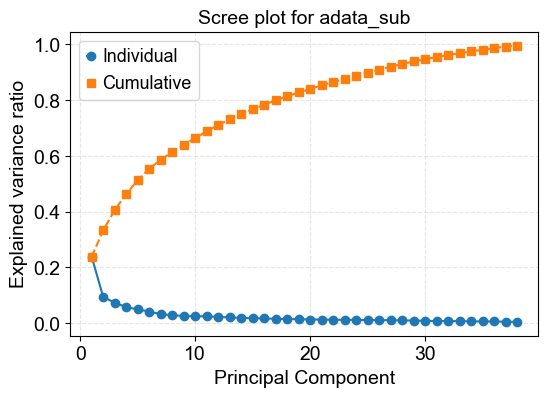

In [30]:
sc.pp.pca(adata_sub, n_comps=38)  # request enough PCs (< no. of markers)

# Scanpy stores variance ratios in adata.uns['pca']
var_exp = adata_sub.uns['pca']['variance_ratio']
cum_var_exp = np.cumsum(var_exp)

plt.figure(figsize=(6,4))
plt.plot(range(1, len(var_exp)+1), var_exp, 'o-', label="Individual")
plt.plot(range(1, len(var_exp)+1), cum_var_exp, 's--', label="Cumulative")
plt.xlabel("Principal Component")
plt.ylabel("Explained variance ratio")
plt.title("Scree plot for adata_sub")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [31]:
adata_sub

AnnData object with n_obs × n_vars = 355347 × 39
    obs: 'sample', 'Object.ID', 'Image.ID', 'timepoint', 'treatment', 'response', 'treat_setting', 'cell_lineage', 'immune_stroma_lineage', 'cell_type_major', 'immune_stroma_lineage_str', 'immune_subtype', 'myeloid_subtype', 'Tcell_subtype', 'cell_type_minor', 'immune_subtype_str', 'myeloid_subtype_str', 'Tcell_subtype_str', 'pt_response', 'neighborhood20', 'region', 'region_tumour_stroma', 'region_tumour_margin_stroma', 'x', 'y', 'CN_k20_n20', 'CN_k20_n7', 'summary_cell_type', 'CN_k20_n7_annot', 'response_group', 'response_group_ordered', 'itm18_leiden'
    var: 'mean', 'std'
    uns: 'CN_k20_n7_colors', 'Centroid_k20_n20', 'Centroid_k20_n7', 'cell_type_major_colors', 'dendrogram_Tcell_subtype', 'dendrogram_cell_lineage', 'dendrogram_cell_type_major', 'dendrogram_cell_type_minor', 'dendrogram_immune_subtype', 'dendrogram_myeloid_subtype', 'dendrogram_pt_response', 'pca', 'neighbors', 'umap', 'itm18_leiden', 'summary_cell_type_colors', '

In [36]:
fig = sc.pl.embedding(
    adata_sub,
    basis='X_umap_pcs30_nn20_cosine_md0p2',
    color=colors,
    size=5,
    frameon=False,
    show=False,
    return_fig=True,
    wspace=0.4
)

fig.savefig(os.path.join(output_dir, "umap_panels.png"), dpi=300, bbox_inches="tight")
plt.close(fig)

In [41]:
adata

AnnData object with n_obs × n_vars = 3553478 × 39
    obs: 'sample', 'Object.ID', 'Image.ID', 'timepoint', 'treatment', 'response', 'treat_setting', 'cell_lineage', 'immune_stroma_lineage', 'cell_type_major', 'immune_stroma_lineage_str', 'immune_subtype', 'myeloid_subtype', 'Tcell_subtype', 'cell_type_minor', 'immune_subtype_str', 'myeloid_subtype_str', 'Tcell_subtype_str', 'pt_response', 'neighborhood20', 'region', 'region_tumour_stroma', 'region_tumour_margin_stroma', 'x', 'y', 'CN_k20_n20', 'CN_k20_n7', 'summary_cell_type', 'CN_k20_n7_annot', 'response_group', 'response_group_ordered', 'itm18_leiden'
    var: 'mean', 'std'
    uns: 'CN_k20_n7_colors', 'Centroid_k20_n20', 'Centroid_k20_n7', 'cell_type_major_colors', 'dendrogram_Tcell_subtype', 'dendrogram_cell_lineage', 'dendrogram_cell_type_major', 'dendrogram_cell_type_minor', 'dendrogram_immune_subtype', 'dendrogram_myeloid_subtype', 'dendrogram_pt_response', 'pca', 'neighbors', 'umap', 'itm18_leiden', 'summary_cell_type_colors', 

In [78]:
# --- helper: safe % table per sample for a given column (optionally with a row filter) ---
def per_sample_percent(adata, col, row_mask=None, exclude=None):
    df = adata.obs[[col, "sample", "response_group"]].copy()
    if row_mask is not None:
        df = df.loc[row_mask].copy()
    if exclude is not None:
        df = df[~df[col].isin(exclude)].copy()

    # use declared categorical order if present
    if hasattr(adata.obs[col], "cat"):
        categories = list(adata.obs[col].cat.categories)
        if exclude:
            categories = [c for c in categories if c not in exclude]
    else:
        categories = sorted(df[col].unique().tolist())

    # counts per sample, wide
    wide_counts = (
        df.groupby(["sample", col]).size()
          .unstack(fill_value=0)
          .reindex(columns=categories, fill_value=0)
    )
    # convert to %
    wide_pct = wide_counts.div(wide_counts.sum(axis=1), axis=0) * 100.0

    # add sample-level metadata (response_group)
    sample_meta = (
        df.groupby("sample", as_index=True)["response_group"]
          .agg(lambda x: x.iloc[0])
    )
    wide_pct.insert(0, "response_group", sample_meta)

    # long version (optional, often handy)
    long_pct = (
        wide_pct.reset_index()
                .melt(id_vars=["sample", "response_group"],
                      var_name=col, value_name="percent")
    )

    return wide_pct, long_pct

# 1) summary_cell_type (% within each sample)
summ_wide, summ_long = per_sample_percent(
    adata, col="summary_cell_type"
)

# 2) immune subtypes from cell_type_minor (exclude Melanoma/Vessel)
immune_mask = ~adata.obs["cell_type_minor"].isin(["Melanoma", "Vessel"])
imm_wide, imm_long = per_sample_percent(
    adata, col="cell_type_minor", row_mask=immune_mask
)

# --- save CSVs ---
summ_wide.to_csv(os.path.join(output_dir, "per_sample_summary_cell_type_pct_wide.csv"))
summ_long.to_csv(os.path.join(output_dir, "per_sample_summary_cell_type_pct_long.csv"), index=False)

imm_wide.to_csv(os.path.join(output_dir, "per_sample_immune_subtype_pct_wide.csv"))
imm_long.to_csv(os.path.join(output_dir, "per_sample_immune_subtype_pct_long.csv"), index=False)

In [80]:
### Pie chart for all samples

# load the wide summary table (or use `summ_wide` from memory)
summ_wide = pd.read_csv(os.path.join(output_dir, "per_sample_summary_cell_type_pct_wide.csv"))
# separate meta
summ_wide = summ_wide.set_index("sample")
response_group = summ_wide.pop("response_group")

# average across samples
avg = summ_wide.mean(axis=0).sort_values(ascending=False)

vals   = avg.values
labels = avg.index.tolist()
legend_labels = [f"{lab} ({p:.1f}%)" for lab, p in zip(labels, vals)]

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(vals, labels=None, startangle=90, counterclock=False)
ax.axis("equal")
ax.set_title("Proportion of main cell types")

ax.legend(
    legend_labels, title="Cell type",
    loc="center left", bbox_to_anchor=(1, 0.5)
)

outpath = os.path.join(output_dir, "cellpercent_all.png")
plt.tight_layout(); plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.close(fig)

In [82]:
### Pie chart per response group

# ---- load the per-sample % table and prepare it ----
# If you already have summ_wide in memory from A) you can skip the read_csv line.
summ_wide = pd.read_csv(
    os.path.join(output_dir, "per_sample_summary_cell_type_pct_wide.csv"),
    index_col=0           # <-- 'sample' is the index
)

# split off sample-level response group (aligned to the index)
rg = summ_wide.pop("response_group")    # Series indexed by sample

# make sure remaining columns are numeric
summ_wide = summ_wide.apply(pd.to_numeric, errors="coerce")

# ---- define sample groups by index (not cell masks) ----
groups = [
    ("All ITM (n = 18)", summ_wide.index),
    ("PRE Responsive (n = 5)", rg[rg == "PRE_Responsive"].index),
    ("PRE Resistant (n = 3)", rg[rg == "PRE_Resistant"].index),
    ("PROG Resistant (n = 10)", rg[rg == "PROG_Resistant"].index),
]

# ---- plot ----
fig, axes = plt.subplots(1, 4, figsize=(15, 4), constrained_layout=True)

for ax, (title, sample_idx) in zip(axes, groups):
    avg = summ_wide.loc[sample_idx].mean(axis=0, numeric_only=True).sort_values(ascending=False)
    vals = avg.values
    labels = avg.index.tolist()
    legend_labels = [f"{lab} ({v:.1f}%)" for lab, v in zip(labels, vals)]

    ax.pie(vals, labels=None, startangle=90, counterclock=False)
    ax.axis("equal")
    ax.set_title(title)
    ax.legend(
        legend_labels,
        title="Cell type",
        loc="upper center",
        bbox_to_anchor=(0.5, -0.08),
        ncol=2,
        fontsize=9,
        frameon=False
    )

plt.savefig(os.path.join(output_dir, "cellpercent_by_response.png"), dpi=300, bbox_inches="tight")
plt.close(fig)

In [85]:
### Bar plot for all samples

imm_wide = pd.read_csv(os.path.join(output_dir, "per_sample_immune_subtype_pct_wide.csv"))
imm_wide = imm_wide.set_index("sample")
imm_wide.pop("response_group")

avg = imm_wide.mean(axis=0).sort_values(ascending=False).reset_index()
avg.columns = ["Cell Subtype", "Percentage"]
remove = ['Melanoma', 'Vessel']
avg = avg[~avg['Cell Subtype'].isin(remove)]

plt.figure(figsize=(14,6))
ax = sns.barplot(
    data=avg, x="Cell Subtype", y="Percentage",
    order=avg["Cell Subtype"].tolist(), palette="tab20"
)
ax.grid(False)
ax.set_xlabel("")
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{h:.1f}%", (p.get_x()+p.get_width()/2., h),
                    ha="center", va="bottom", fontsize=8)

plt.xticks(rotation=75, ha="right")
plt.ylabel("% of immune cells")
plt.title("Percentage of immune cell subtypes")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "immune_subtypes_bar.png"),
            dpi=300, bbox_inches="tight")
plt.close()

In [96]:
### Bar plot per response group

# --- load per-sample immune % (wide) with sample as index ---
imm_wide = pd.read_csv(
    os.path.join(output_dir, "per_sample_immune_subtype_pct_wide.csv"),
    index_col=0            # <- makes 'sample' the index, not a column
)

# pull out response_group (aligned to the same sample index)
rg = imm_wide.pop("response_group")     # Series indexed by sample

# ensure all remaining columns are numeric
imm_wide = imm_wide.apply(pd.to_numeric, errors="coerce")

# remove unwanted columns
remove = ['Melanoma', 'Vessel']
imm_wide = imm_wide.drop(columns=[c for c in remove if c in imm_wide.columns], errors="ignore")

# overall order for x-axis (descending average % across samples)
order = imm_wide.mean(axis=0, skipna=True).sort_values(ascending=False).index.tolist()

# helper: group-average (by sample) and return tidy df in that fixed order
def group_avg(sample_idx):
    avg = imm_wide.loc[sample_idx].mean(axis=0, skipna=True).reindex(order)
    df = avg.reset_index()
    df.columns = ["Cell Subtype", "Percentage"]
    return df

# define sample groups by index (not cell-level masks)
samples = imm_wide.index
groups = [
    ("All ITM (n = 18)", samples),
    ("PRE Responsive (n = 5)", rg[rg == "PRE_Responsive"].index),
    ("PRE Resistant (n = 3)", rg[rg == "PRE_Resistant"].index),
    ("PROG Resistant (n = 10)", rg[rg == "PROG_Resistant"].index),
]

# compute group averages
dfs = [group_avg(idx) for _, idx in groups]
ymax = np.ceil(max(d["Percentage"].max() for d in dfs) / 2) * 2

# --- plot ---
fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True)

for ax, (title, _), df in zip(axes, groups, dfs):
    sns.barplot(data=df, x="Cell Subtype", y="Percentage",
                order=order, palette="tab20", ax=ax)
    ax.grid(False)
    ax.set_ylim(0, ymax)
    ax.set_ylabel("% of immune cells")
    ax.set_title(title)
    # remove spines
    sns.despine(ax=ax)

    # annotate bars
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.annotate(f"{h:.1f}%",
                        (p.get_x()+p.get_width()/2., h),
                        ha="center", va="bottom", fontsize=12)

# hide x labels for top 3
for ax in axes[:-1]:
    ax.tick_params(axis='x', which='both', labelbottom=False)

# bottom axis with rotated labels
axes[-1].tick_params(axis='x', labelbottom=True)
plt.setp(axes[-1].get_xticklabels(), rotation=75, ha='right')
axes[-1].set_xlabel("")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "immune_subtypes_bar_by_response_sharedx.png"),
            dpi=300, bbox_inches="tight")
plt.close(fig)

In [153]:
### Stacked bar per region grouped by response

# ---------- 1) Consistent order & colors ----------
imm_wide = pd.read_csv(
    os.path.join(output_dir, "per_sample_immune_subtype_pct_wide.csv"),
    index_col=0
)
rg = imm_wide.pop("response_group")
imm_wide = imm_wide.apply(pd.to_numeric, errors="coerce")

# drop Melanoma/Vessel explicitly from reference data
remove = ['Melanoma', 'Vessel']
imm_wide = imm_wide.drop(columns=[c for c in remove if c in imm_wide.columns], errors="ignore")

# subtype order
order = imm_wide.mean(axis=0, skipna=True).sort_values(ascending=False).index.tolist()

# fixed palette & color mapping (only immune subtypes)
palette = sns.color_palette("tab20", n_colors=max(20, len(order)))
color_map = {ct: palette[i % len(palette)] for i, ct in enumerate(order)}

# ---------- 2) Build per-sample % within REGION ----------
obs = adata.obs[['sample', 'response_group', 'region', 'cell_type_minor']].copy()
obs = obs[~obs['cell_type_minor'].isin(remove)]  # drop here too

wide = (
    obs.groupby(['sample', 'region', 'cell_type_minor']).size()
       .unstack('cell_type_minor', fill_value=0)
)
wide = wide.reindex(columns=order, fill_value=0)
wide_pct = wide.div(wide.sum(axis=1), axis=0).fillna(0) * 100.0

sample_rg = obs[['sample', 'response_group']].drop_duplicates().set_index('sample')['response_group']
wide_pct = wide_pct.reset_index().set_index('sample')
wide_pct.insert(0, 'response_group', sample_rg.reindex(wide_pct.index))

# ---------- 3) Average across samples ----------
region_order = [('tumor', 'Tumour'), ('tumor_margin', 'Margin'), ('stroma', 'Stroma')]
group_keys  = ['PRE_Responsive', 'PRE_Resistant', 'PROG_Resistant']
group_titles = ['PRE Responsive (n = 5)', 'PRE Resistant (n = 3)', 'PROG Resistant (n = 10)']

avg_by_region = {}
for reg_key, _ in region_order:
    reg_df = wide_pct[wide_pct['region'] == reg_key].drop(columns=['region'])
    frame = {}
    for gk, glab in zip(group_keys, group_titles):
        samp_idx = reg_df.index[reg_df['response_group'] == gk]
        vals = reg_df.loc[samp_idx, order].mean(axis=0, skipna=True) if len(samp_idx) else pd.Series(0, index=order)
        frame[glab] = vals
    avg_by_region[reg_key] = pd.DataFrame(frame).loc[order]

# ---------- 4) Plot ----------
fig, axes = plt.subplots(1, 3, figsize=(10, 7), sharey=True)
for ax, (reg_key, reg_title) in zip(axes, region_order):
    M = avg_by_region[reg_key]
    x = np.arange(len(group_titles))
    bottom = np.zeros_like(x, dtype=float)

    for subtype in order:
        heights = M.loc[subtype, group_titles].values
        ax.bar(x, heights, bottom=bottom, color=color_map[subtype], width=0.8, 
               edgecolor="#f0f0f0", linewidth=0.4, label=subtype)
        bottom += heights

    ax.set_xticks(x, group_titles, rotation=90, ha='center')
    ax.set_ylim(0, 100)
    ax.set_title(reg_title)
    ax.set_ylabel('Cell percentage' if ax is axes[0] else '')
    ax.grid(False)
    sns.despine(ax=ax)

# legend with only immune subtypes (Melanoma/Vessel removed)
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, title='Cell Type', loc='center left', bbox_to_anchor=(1.01, 0.5), ncol=1)

plt.tight_layout()
plt.subplots_adjust(wspace=0.05)  # smaller = less horizontal space
plt.savefig(os.path.join(output_dir, "immune_stacked_by_region_response.png"),
            dpi=300, bbox_inches='tight')
plt.close(fig)

In [152]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# ---------- 1) Consistent colors from alphabetical subtype order ----------
imm_wide = pd.read_csv(
    os.path.join(output_dir, "per_sample_immune_subtype_pct_wide.csv"),
    index_col=0
)
rg = imm_wide.pop("response_group")
imm_wide = imm_wide.apply(pd.to_numeric, errors="coerce")

# remove non-immune
remove = ['Melanoma', 'Vessel']
imm_wide = imm_wide.drop(columns=[c for c in remove if c in imm_wide.columns], errors="ignore")

# alphabetical order for color assignment (keeps T_* together)
alpha_order = sorted(imm_wide.columns, key=str)

# use seaborn 'tab20b' palette for consistent colors
palette = sns.color_palette("tab20b", n_colors=len(alpha_order))
color_map = {ct: palette[i % len(palette)] for i, ct in enumerate(alpha_order)}

# ---------- 2) Build per-sample % within REGION (immune-only) ----------
obs = adata.obs[['sample', 'response_group', 'region', 'cell_type_minor']].copy()
obs = obs[~obs['cell_type_minor'].isin(remove)]

wide = (
    obs.groupby(['sample', 'region', 'cell_type_minor']).size()
       .unstack('cell_type_minor', fill_value=0)
)
# ensure all subtypes are present and in alpha order for color_map alignment
wide = wide.reindex(columns=alpha_order, fill_value=0)

wide_pct = wide.div(wide.sum(axis=1), axis=0).fillna(0) * 100.0

sample_rg = (obs[['sample', 'response_group']]
             .drop_duplicates()
             .set_index('sample')['response_group'])
wide_pct = wide_pct.reset_index().set_index('sample')
wide_pct.insert(0, 'response_group', sample_rg.reindex(wide_pct.index))

# ---------- 3) Average across samples (per region and per response group) ----------
region_order  = [('tumor', 'Tumour'), ('tumor_margin', 'Margin'), ('stroma', 'Stroma')]
group_keys    = ['PRE_Responsive', 'PRE_Resistant', 'PROG_Resistant']
group_titles  = ['PRE Responsive (n = 5)', 'PRE Resistant (n = 3)', 'PROG Resistant (n = 10)']

# map keys->titles once
gkey_to_title = dict(zip(group_keys, group_titles))

avg_by_region = {}
for reg_key, _ in region_order:
    reg_df = wide_pct[wide_pct['region'] == reg_key].drop(columns=['region'])
    frame = {}
    for gk in group_keys:
        samp_idx = reg_df.index[reg_df['response_group'] == gk]
        vals = (reg_df.loc[samp_idx, alpha_order].mean(axis=0, skipna=True)
                if len(samp_idx) else pd.Series(0, index=alpha_order))
        frame[gkey_to_title[gk]] = vals
    avg_by_region[reg_key] = pd.DataFrame(frame).loc[alpha_order]  # rows=subtypes

# ---------- 4) Plot (stack each bar by its own descending proportion) ----------
fig, axes = plt.subplots(1, 3, figsize=(10, 7), sharey=True)

for ax, (reg_key, reg_title) in zip(axes, region_order):
    M = avg_by_region[reg_key]         # index=subtypes, columns=group_titles
    x = np.arange(len(group_titles))    # positions for 3 groups

    # draw each bar independently with its own descending stack order
    for gi, gtitle in enumerate(group_titles):
        s = M[gtitle].sort_values(ascending=False)  # largest --> smallest
        bottom = 0.0
        for subtype in s.index:
            h = s[subtype]
            if h <= 0:
                continue
            ax.bar(x[gi], h, bottom=bottom, width=0.8,
                   color=color_map[subtype])
            bottom += h

    ax.set_xticks(x, labels=group_titles, rotation=90, ha='center')
    ax.set_ylim(0, 100)
    ax.set_title(reg_title)
    ax.set_ylabel('Cell percentage' if ax is axes[0] else '')
    ax.grid(False)
    sns.despine(ax=ax)

# custom legend (stable alphabetical order)
legend_patches = [Patch(facecolor=color_map[ct], label=ct) for ct in alpha_order]
fig.legend(legend_patches, [p.get_label() for p in legend_patches],
           title='Cell Type', loc='center left', bbox_to_anchor=(1.01, 0.5), ncol=1)

plt.tight_layout()
plt.subplots_adjust(wspace=0.05)
plt.savefig(os.path.join(output_dir, "immune_stacked_by_region_response_tab20b_alpha.png"),
            dpi=300, bbox_inches='tight')
plt.close(fig)

In [121]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal
import os

order_groups = [
    "PRE Responsive (n = 5)",
    "PRE Resistant (n = 3)",
    "PROG Resistant (n = 10)",
]
palette = {
    "PRE Responsive (n = 5)": "#F9E58A",
    "PRE Resistant (n = 3)":  "#7AB7BA",
    "PROG Resistant (n = 10)": "#8EA5AA",
}

df_tumour = df.rename(columns={"percent": "Percentage"}).copy()

plt.figure(figsize=(5, 6))
ax = sns.violinplot(
    data=df_tumour, x="group_label", y="Percentage",
    order=order_groups, palette=palette,
    cut=2,                 # <--- extend KDE beyond data (full shape)
    inner=None, linewidth=1
)
sns.stripplot(
    data=df_tumour, x="group_label", y="Percentage",
    order=order_groups, color="k", size=5, alpha=0.9, jitter=True, ax=ax
)

ax.set_xlabel("")
ax.set_ylabel("Cell percentage")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")
ax.set_title("CD141$^{+}$ DC (Tumour)", pad=12)
ax.grid(False)

# add padding below and above so violins are not cut off
ymin = df_tumour["Percentage"].min() - 15
ymax = df_tumour["Percentage"].max() + 25
ax.set_ylim(ymin, ymax)

# ---- global Kruskal–Wallis ----
kw_stat, kw_p = kruskal(
    *[df_tumour.loc[df_tumour["group_label"] == g, "Percentage"].values for g in order_groups]
)

# bracket position based on ymax so it's above the violin
x0, x1 = -0.2, len(order_groups) - 0.8
y_kw = ymax * 0.85   # push the line up higher
ax.plot([x0, x1], [y_kw, y_kw], color="k", linewidth=1)
ax.text((x0 + x1) / 2, y_kw + (ymax - ymin) * 0.03,
        f"Kruskal–Wallis $P$ = {kw_p:.4g}",
        ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "DC_CD141_tumour_violin.png"),
            dpi=300, bbox_inches="tight")
plt.close()

In [149]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal
import os

# ---------- shared settings ----------
order_groups = [
    "PRE Responsive (n = 5)",
    "PRE Resistant (n = 3)",
    "PROG Resistant (n = 10)",
]
palette = {
    "PRE Responsive (n = 5)": "#F9E58A",
    "PRE Resistant (n = 3)":  "#7AB7BA",
    "PROG Resistant (n = 10)": "#8EA5AA",
}
# map from response_group to pretty labels you used earlier
group_map = {
    "PRE_Responsive": order_groups[0],
    "PRE_Resistant":  order_groups[1],
    "PROG_Resistant": order_groups[2],
}
remove = ["Melanoma", "Vessel"]  # immune-only denominator

def per_sample_percent_for(adata, subtype, region_key):
    """
    Build a per-sample % DataFrame for `subtype` within `region_key`,
    among immune cells only (Melanoma/Vessel excluded).
    Returns df with columns: ['Percentage','group_label'] (index = sample)
    """
    obs = adata.obs[["sample","response_group","region","cell_type_minor"]].copy()
    obs = obs[(obs["region"] == region_key) & (~obs["cell_type_minor"].isin(remove))]

    # denominator: immune cells per sample in region
    den = obs.groupby("sample").size().rename("den")

    # numerator: chosen subtype per sample in region
    num = (
        obs[obs["cell_type_minor"].astype(str) == subtype]
        .groupby("sample").size().rename("num")
    )

    df = pd.concat([den, num], axis=1).fillna(0)
    df["Percentage"] = (df["num"] / df["den"] * 100).fillna(0)

    # attach group labels
    sample_rg = (adata.obs[["sample","response_group"]]
                 .drop_duplicates()
                 .set_index("sample")["response_group"])
    df["group_label"] = sample_rg.reindex(df.index).map(group_map)
    df = df[df["group_label"].isin(order_groups)].copy()
    return df[["Percentage","group_label"]]

def plot_violin(df_region, title, outfile, custom_ylim=None):
    """Make violin+points plot with optional custom y-axis range and KW stats."""
    plt.figure(figsize=(4, 6))
    ax = sns.violinplot(
        data=df_region, x="group_label", y="Percentage",
        order=order_groups, palette=palette,
        cut=2, inner=None, linewidth=1.5, edgecolor="black"
    )
    sns.stripplot(
        data=df_region, x="group_label", y="Percentage",
        order=order_groups, color="k", size=3, alpha=0.9, jitter=True, ax=ax
    )

    ax.set_xlabel("")
    ax.set_ylabel("Cell percentage")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")
    ax.set_title(title, pad=12)
    ax.grid(False)

    # --- y-axis limits ---
    if custom_ylim:
        ymin, ymax = custom_ylim
    else:
        ymin = df_region["Percentage"].min() - 15
        ymax = df_region["Percentage"].max() + 25
    ax.set_ylim(ymin, ymax)

    # --- Kruskal–Wallis ---
    kw_stat, kw_p = kruskal(*[
        df_region.loc[df_region["group_label"] == g, "Percentage"].values
        for g in order_groups
    ])

    # bracket position based on ymax
    x0, x1 = -0.2, len(order_groups) - 0.8
    y_kw = ymax * 0.85
    ax.plot([x0, x1], [y_kw, y_kw], color="k", linewidth=1)
    ax.text((x0+x1)/2, y_kw + (ymax - ymin) * 0.03,
            f"Kruskal–Wallis $P$ = {kw_p:.3g}",   # <--- 3 sig figs
            ha="center", va="bottom", fontsize=11)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, outfile), dpi=300, bbox_inches="tight")
    plt.close()

In [143]:
sorted(adata.obs["cell_type_minor"].unique())

['Bcell',
 'DC_CD141',
 'Immune_other',
 'Melanoma',
 'Myeloid_other',
 'Mφ_CD11b',
 'Mφ_CD11b_CD11c_HIF.1a',
 'Mφ_CD11b_HIF.1a',
 'Mφ_CD11c_PDL1',
 'Mφ_CD14_CD163',
 'Mφ_CD14_CD163_CD206',
 'Mφ_CD14_CD163_HLA.DR',
 'Mφ_CD206_CD11b_PDL1',
 'Mφ_CD68',
 'Mφ_CD68_HLA.DR_PDL1',
 'Mφ_HLA.DR_C1q_PDL1',
 'T_CD39_TIGIT',
 'T_CD4_C1q',
 'T_CD4_CD39_HIF.1a',
 'T_CD4_CD39_TIGIT',
 'T_CD4_CD45RO',
 'T_CD4_Foxp3_ICOS',
 'T_CD4_HIF.1a_VISTA',
 'T_CD4_IDO1_HLA.DR',
 'T_CD8_CD39',
 'T_CD8_GZMB',
 'T_CD8_Ki67',
 'T_HLA.DR_TIGIT',
 'T_other',
 'Vessel']

In [150]:
# 1) DC_CD141 — Tumour
df_tumour = per_sample_percent_for(adata, subtype="DC_CD141", region_key="tumor")
plot_violin(df_tumour, "CD141$^{+}$ DC (Tumour)", "DC_CD141_tumour_violin.png")

# 2) DC_CD141 — Stroma
df_stroma = per_sample_percent_for(adata, subtype="DC_CD141", region_key="stroma")
plot_violin(df_stroma, "CD141$^{+}$ DC (Stroma)", "DC_CD141_stroma_violin.png")

# 3) DC_CD141 — Margin
df_margin = per_sample_percent_for(adata, subtype="DC_CD141", region_key="tumor_margin")
plot_violin(df_margin, "CD141$^{+}$ DC (Margin)", "DC_CD141_margin_violin.png")

# 4) Myeloid_other — Stroma
df_myo_stroma = per_sample_percent_for(adata, subtype="Myeloid_other", region_key="stroma")
plot_violin(df_myo_stroma, "Myeloid other (Stroma)", "Myeloid_other_stroma_violin.png",
            custom_ylim=(-2, 6))

In [151]:
# 5) Mφ_CD11c_PDL1 - Margin
df_mac_margin = per_sample_percent_for(adata, subtype="Mφ_CD11c_PDL1", region_key="tumor_margin")
plot_violin(df_mac_margin, "CD11c$^{+}$PDL1$^{+}$ Mφ (Margin)", "Mac_CD11cPDL1_margin_violin.png")

# 6) T_HLA.DR_TIGIT - Margin
df_t_margin = per_sample_percent_for(adata, subtype="T_HLA.DR_TIGIT", region_key="tumor_margin")
plot_violin(df_t_margin, "HLA-DR$^{+}$TIGIT$^{+}$ T cell (Margin)", "T_HLAdrTIGIT_margin_violin.png")